
# **TMS 2025 AI Workshop: Ryan Jacobs, Ben Afflerbach, Dane Morgan (UW-Madison)**

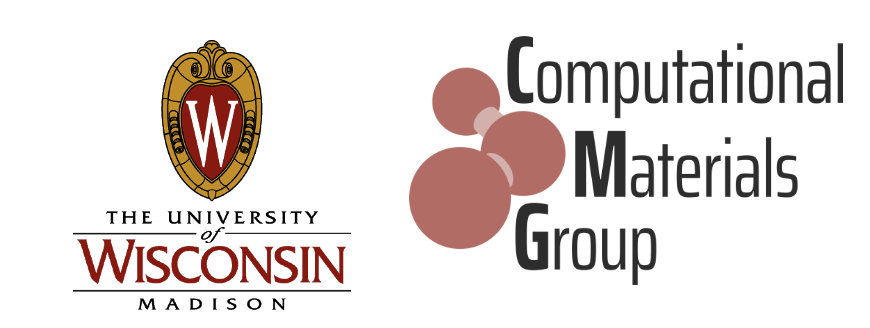

---


## Google Colab notebook for fitting elemental properties:
## example of conditional generation of high voltage Na-battery materials

# Installation and setup

To begin, we need to install or import a few needed python packages.

In [1]:
# Installs
# The following gives and error and asks to restart the session. Just do that and rerun.
# Materials specific packages (this takes a few minutes first time, about 1 min after restart).
#!pip install pymatgen mp_api             # A useful package for working with materials data.
#!pip install mastml==3.2.4                        # Materials related ML package
#!pip install numpy==1.26.4
!pip install mastml

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 106.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.8/111.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.6/119.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.0/4

In [1]:
# Imports (This takes about 1 min). Has a few errors and warnings but it seems we can ignore those.
from mastml.mastml import Mastml
from mastml.datasets import LocalDatasets
from mastml.data_cleaning import DataCleaning
from mastml.preprocessing import SklearnPreprocessor
from mastml.models import SklearnModel
from mastml.data_splitters import SklearnDataSplitter, NoSplit
from mastml.mastml_predictor import make_prediction
from mastml.feature_selectors import EnsembleModelFeatureSelector, NoSelect, SklearnFeatureSelector, MASTMLFeatureSelector
from mastml.feature_selectors import ShapFeatureSelector
from mastml.feature_generators import ElementalFeatureGenerator
from mastml.learning_curve import LearningCurve
from mastml.hyper_opt import GridSearch
from mastml.hyper_opt import GridSearch

# Python utilities packages
#!pip install pandas
import os                        # OS stands for Operating System and provides ways for python to interact with files or directories
from collections import Counter  # Collections is a package for handling data
from pprint import pprint

import pandas as pd              # Pandas is a data analysis library which we'll primarily use to handle our dataset
import numpy as np               # Numpy is a package for scientific computing. We'll use it for some of it's math functions
import pymatgen                  # Pymatgen is a library for materials analysis which we use to interpret our material compositions
from pymatgen import core as pymatgen_core       # Needed to get core to be accessible.  Note sure why. 9/5/23.

import matplotlib                # Matplotlib is the plotting package that we'll use throughout the lab
import matplotlib.pyplot as plt
import seaborn as sns            # Seaborn is a Python data visualization library based on matplotlib

Figshare is an optional dependency. To import data from figshare, manually install figshare via git clone of git clone https://github.com/cognoma/figshare.git


ERROR:duecredit:Failed to import duecredit due to No module named 'duecredit'


scikit-lego is an optional dependency, enabling use of the LowessRegression model. If you want to use this model, do "pip install scikit-lego"
linear-tree is an optional dependency, enabling use of Linear tree, forest, and boosting models. If you want to use this model, do "pip install linear-tree"
gplearn is an optional dependency, enabling the use of genetic programming SymbolicRegressor model. If you want to use this model, do "pip install gplearn"
sklearn-extra is an optional dependency, used to do LeaveOutClusterCV. To use it, do pip install sklearn_extra
CBFV is an optional dependency. To install CBFV, do pip install cbfv
DeepChem is an optional dependency used to generate molecular descriptors from RDKit. To install Deepchem, do pip install deepchem


# Obtaining the data used for fitting

There is a saved data file in the Google Drive which contains the calculated
average voltage of Na insertion. The data were obtained by screening materials
from the Materials Project and calculting the voltage using a Universal
Machine Learning Interatomic Potential (U-MLIP)

This cell links your Google drive to the Colab session

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Set up path to directory with input files and where output will be sent. Checks that the path name is assigned correctly.

In [4]:
#d = '/content/drive/MyDrive/Online Filed/Dane Morgan Mixed Sharing/Projects/TMS AI4MSE for DEMO 2025-10-28/Sec 1 Elemental'
d = '/content/drive/MyDrive/TMS_2025_AI_workshop/'
!echo $d
os.path.isdir(d)

/content/drive/MyDrive/TMS_2025_AI_workshop/


True

Load datafile

In [7]:
import joblib
df = joblib.load(os.path.join(d, 'mp_Na_eqV2.pkl'))
df.head()

,index,"Relaxed structure, full","Relaxed structure, empty","Relaxed structure, ref","Relaxed energy, full","Relaxed energy, empty","Relaxed energy, ref","Relaxed volume, full","Relaxed volume, empty",Average voltage (V/ion),mp_id,Composition,Structure
0,0,"{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...",-47.144470,-42.739342,-2.612235,86.925992,82.302897,3.099011,mp-1002571-GGA+U,NaMn2O4,"[[ 1.4537295 -0.858677 2.8019015] Na, [0. 0...."
1,0,"{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...",-347.147003,-342.174774,-2.612235,580.632428,580.309435,3.666111,mp-1003635-GGA+U,NaMn16O32,"[[4.97042764 4.96925164 4.40963713] Na, [6.467..."
2,0,"{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...",-360.532379,-342.138519,-2.612235,592.342169,578.011476,3.292347,mp-1003636-GGA+U,NaMn4O8,"[[3.75601408 7.43825464 1.65457529] Na, [ 5.16..."
3,0,"{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...",-351.932495,-342.103943,-2.612235,585.379022,583.089731,3.608158,mp-1003638-GGA+U,NaMn8O16,"[[-4.9288659 5.00872719 -1.47329048] Na, [-9..."
4,0,"{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...",-93.682617,-84.215996,-2.612235,162.257705,136.842690,3.427193,mp-1003766-GGA+U,NaMn2O4,"[[1.46205272 2.17082951 8.89991039] Na, [1.462..."


The data file contains U-MLIP relaxed structures and average voltages for 2288 materials. Let's plot a histogram of the computed average voltages to see their distribution:

In [8]:
def plot_voltage_histogram(df, dataset='MP', ion='Na'):
    bins = np.arange(0, 10, 0.2)

    # Matterverse avg voltage has a bunch of negative values- remove them!
    df = df[df['Average voltage (V/ion)'] >=0]

    plt.clf()

    plt.hist(bins=bins, x=df['Average voltage (V/ion)'], color='red', edgecolor='black', alpha=0.5, label='EquiformerV2')

    plt.xlabel('Average voltage (V/Na)', fontsize=14)
    plt.xticks(fontsize=12)
    plt.ylabel('Number of occurrences', fontsize=14)
    plt.yticks(fontsize=12)
    plt.legend(loc='best')
    plt.savefig('Voltage_histogram_'+dataset+'_'+ion+'.png', dpi=300, bbox_inches='tight')

    vals = df['Average voltage (V/ion)']
    print('EquiformerV2 voltage stats')
    fmt = lambda x: np.format_float_positional(x, precision=3, unique=False, fractional=False, trim='k')

    print(f"{'Mean:':25s}{fmt(np.mean(vals)):>12s}")
    print(f"{'Standard deviation:':25s}{fmt(np.std(vals)):>12s}")
    print(f"{'Min:':25s}{fmt(min(vals)):>12s}")
    print(f"{'Max:':25s}{fmt(max(vals)):>12s}")

    return

EquiformerV2 voltage stats
Mean:                            4.13
Standard deviation:             0.916
Min:                            0.524
Max:                             6.92


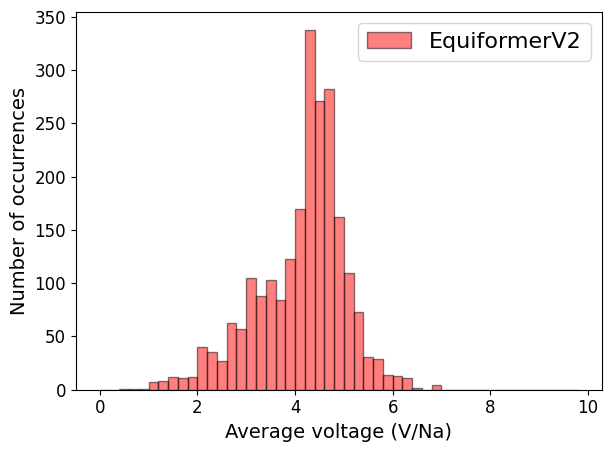

In [9]:
plot_voltage_histogram(df)

As we can see, the average voltage is around 4.1 V/Na, with numerous instances of high voltage materials.

Since we only need composition as features and voltage as targets, we next pull out those columns as X and y.

In [10]:
# Create X and y as DataFrames
X = df[['Composition']].copy()
y = df[['Average voltage (V/ion)']].copy()

# Display combined view
display(pd.concat([X, y], axis=1))


,Composition,Average voltage (V/ion)
0,NaMn2O4,3.099011
1,NaMn16O32,3.666111
2,NaMn4O8,3.292347
3,NaMn8O16,3.608158
4,NaMn2O4,3.427193
...,...,...
2283,Na2NbF6,4.609173
2284,KNaMo(OF2)2,5.198510
2285,Na3Mn2SbO6,2.778885
2286,NaCuO2,4.159726


# Generate features

Now we generate features with MAST-ML

In [11]:
# X: DataFrame with a 'composition' column of formula strings
# e.g., X = pd.DataFrame({'composition': ['Fe2O3', 'Al2O3', 'NiTi']})

# Build generator from the compositions in X

composition_df=X[['Composition']]

efg = ElementalFeatureGenerator(
    composition_df,   # pass only the composition column
    feature_types=['composition_avg', 'max' , 'min', 'difference'],    # use available elemental features
    remove_constant_columns=True
)

# Generate elemental features
X_elem, ytemp = efg.evaluate(X=X, y=None, savepath=d, make_new_dir=True)                # returns a DataFrame of features

display(X_elem)

Featurizing compositions:: 2288it [00:01, 1231.86it/s]


Dropping 4/352 generated columns due to missing values


,Composition,AtomicNumber_composition_average,AtomicNumber_difference,AtomicNumber_max_value,AtomicNumber_min_value,AtomicRadii_composition_average,AtomicRadii_difference,AtomicRadii_max_value,AtomicRadii_min_value,AtomicVolume_composition_average,...,n_ws^third_max_value,n_ws^third_min_value,phi_composition_average,phi_difference,phi_max_value,phi_min_value,valence_composition_average,valence_difference,valence_max_value,valence_min_value
0,NaMn2O4,13.285714,17.0,25.0,8.0,1.042857,1.17,1.90,0.73,10633.236058,...,1.61,0.82,1.657143,1.75,4.45,2.70,3.285714,6.0,7.0,1.0
1,NaMn16O32,13.612245,17.0,25.0,8.0,0.920408,1.17,1.90,0.73,12146.635733,...,1.61,0.82,1.508163,1.75,4.45,2.70,3.612245,6.0,7.0,1.0
2,NaMn4O8,13.461538,17.0,25.0,8.0,0.976923,1.17,1.90,0.73,11448.143575,...,1.61,0.82,1.576923,1.75,4.45,2.70,3.461538,6.0,7.0,1.0
3,NaMn8O16,13.560000,17.0,25.0,8.0,0.940000,1.17,1.90,0.73,11904.491785,...,1.61,0.82,1.532000,1.75,4.45,2.70,3.560000,6.0,7.0,1.0
4,NaMn2O4,13.285714,17.0,25.0,8.0,1.042857,1.17,1.90,0.73,10633.236058,...,1.61,0.82,1.657143,1.75,4.45,2.70,3.285714,6.0,7.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2283,Na2NbF6,13.000000,32.0,41.0,9.0,1.061000,1.18,1.90,0.72,12411.836688,...,1.64,0.82,1.050000,1.35,4.05,2.70,1.444444,4.0,5.0,1.0
2284,KNaMo(OF2)2,13.777778,34.0,42.0,8.0,1.105778,1.63,2.35,0.72,12413.512853,...,1.77,0.65,1.066667,2.40,4.65,2.25,1.777778,5.0,6.0,1.0
2285,Na3Mn2SbO6,15.166667,43.0,51.0,8.0,1.179167,1.17,1.90,0.73,9310.509568,...,1.61,0.82,1.783333,1.75,4.45,2.70,2.833333,6.0,7.0,1.0
2286,NaCuO2,14.000000,21.0,29.0,8.0,1.159500,1.17,1.90,0.73,9308.915651,...,1.47,0.82,1.787500,1.75,4.45,2.70,1.750000,1.0,2.0,1.0


# Fit model

This section fits the elemental features with Regression using either a Ridge (a kind of regularized linear model) or Random Forest (a powerful tree based model) model. We also have to option to perform feature reduction by taking just a subset of principle components. The code does an 80/20 train/test split and 5-fold Cross-Validation (CV), which are standard ways to test the data.

Start by loading some relevant ML tools (scikit-learn, a widely used ML package) and setting up global variables to control the fit (choice of PCA and model type).

In [ ]:
print("Starting workflow with optional PCA feature reduction...\n")

# Core sklearn imports
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge  # <-- added for optional linear model

# ======= PCA options =======
USE_PCA = True            # <- turn PCA on/off (True or False)
PCA_VAR_KEEP = 0.95       # keep 95% variance (sklearn PCA allows float in (0,1])
# ===========================

# ======= Model option =======
MODEL_TYPE = "ridge"         # one of: "rf", "ridge"
# ===========================



Starting workflow with optional PCA feature reduction...



Now we pull out the X and y features and target wiht right format, cleaning out any data that are not numbers.

In [ ]:
# 1) Prepare data (assumes X_elem dataframe, y array-like)
print("[1/7] Preparing data...")
X = X_elem.copy()
y = df['Average voltage (V/ion)'].values.ravel()  # ensure 1D target

# Keep only numeric columns and drop rows with NaNs/Infs
X = X.select_dtypes(include=np.number)
mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
X, y = X.loc[mask], y[mask]

print(f"   -> Data after cleaning: {X.shape[0]} samples, {X.shape[1]} features")
print("   -> Example feature cols:", list(X.columns[:5]), "\n")

[1/7] Preparing data...
   -> Data after cleaning: 2288 samples, 348 features
   -> Example feature cols: ['AtomicNumber_composition_average', 'AtomicNumber_difference', 'AtomicNumber_max_value', 'AtomicNumber_min_value', 'AtomicRadii_composition_average'] 



Build the model pipeline (including choosing the model). This pipeline tells the code the steps needed in the fitting (scaling, PCA, model fit) so we can run them easily and apply them to train and test data.

In [ ]:
# 2) Build the modeling pipeline: [Scaler] -> [PCA?] -> [Model]
model_name = "RF" if MODEL_TYPE == "rf" else "Ridge"
print("[2/7] Building pipeline (Scaler -> {} -> {})...".format("PCA" if USE_PCA else "No PCA", model_name))
steps = [("scaler", StandardScaler())]
if USE_PCA:
    steps.append(("pca", PCA(n_components=PCA_VAR_KEEP, svd_solver="auto", random_state=0)))

# choose model
if MODEL_TYPE == "rf":
    model = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
elif MODEL_TYPE == "ridge":
    model = Ridge(alpha=1.0, random_state=0)
else:
    raise ValueError("MODEL_TYPE must be 'rf' or 'ridge'")

steps.append(("model", model))
pipe = Pipeline(steps)

[2/7] Building pipeline (Scaler -> PCA -> Ridge)...


Set up the Test/Train split, run the fit no train, and evaluate on train and test.

In [ ]:
# 3) Train/test split (80/20)
print("[3/7] Splitting data (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)
print(f"   -> Train: {X_train.shape}, Test: {X_test.shape}\n")

# 4) Fit on the training set
print("[4/7] Fitting pipeline on training data...")
pipe.fit(X_train, y_train)
print("   -> Fit complete.")
if USE_PCA:
    # Access the fitted PCA to report components retained
    pca = pipe.named_steps["pca"]
    print(f"   -> PCA retained {pca.n_components_} components "
          f"({pca.explained_variance_ratio_.sum():.3f} variance)\n")
else:
    print("   -> PCA disabled.\n")

# 5) Evaluate on train & test
print("[5/7] Evaluating holdout performance...")
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

y_pred_train = pipe.predict(X_train)
y_pred_test  = pipe.predict(X_test)

mae_tr, rmse_tr, r2_tr = metrics(y_train, y_pred_train)
mae_te, rmse_te, r2_te = metrics(y_test,  y_pred_test)

print("=== Holdout Performance (80/20 split) ===")
print(f"Train: MAE={mae_tr:.4f}, RMSE={rmse_tr:.4f}, R²={r2_tr:.4f}")
print(f"Test : MAE={mae_te:.4f}, RMSE={rmse_te:.4f}, R²={r2_te:.4f}\n")

[3/7] Splitting data (80/20)...
   -> Train: (1830, 348), Test: (458, 348)

[4/7] Fitting pipeline on training data...
   -> Fit complete.
   -> PCA retained 32 components (0.953 variance)

[5/7] Evaluating holdout performance...
=== Holdout Performance (80/20 split) ===
Train: MAE=0.4827, RMSE=0.6756, R²=0.4525
Test : MAE=0.4898, RMSE=0.6959, R²=0.4386



Do cross validation to get good statistics on left out "test" data.

In [ ]:
# 6) 5-fold cross-validation (uses the SAME pipeline to avoid leakage)
print("[6/7] Running 5-fold cross-validation...")
cv = KFold(n_splits=5, shuffle=True, random_state=0)
cv_results = cross_validate(
    pipe, X, y,
    cv=cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1,
    return_train_score=False
)

cv_mae  = -cv_results["test_mae"]
cv_rmse = -cv_results["test_rmse"]
cv_r2   =  cv_results["test_r2"]

print("=== 5-Fold Cross-Validation (entire dataset) ===")
print(f"MAE : mean={cv_mae.mean():.4f} ± {cv_mae.std():.4f}")
print(f"RMSE: mean={cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
print(f"R²  : mean={cv_r2.mean():.4f} ± {cv_r2.std():.4f}\n")

[6/7] Running 5-fold cross-validation...
=== 5-Fold Cross-Validation (entire dataset) ===
MAE : mean=0.4953 ± 0.0147
RMSE: mean=0.6938 ± 0.0174
R²  : mean=0.4223 ± 0.0433



Now plot results as parity plots.

[7/7] Generating parity plots...


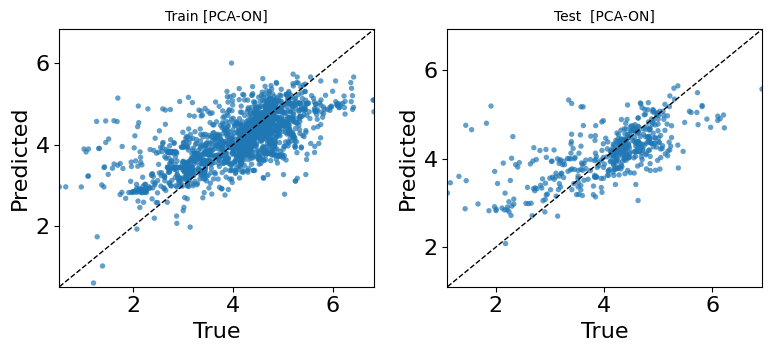


✅ Workflow complete.


In [ ]:
# 7) Parity plots for Train and Test (side-by-side, smaller)
print("[7/7] Generating parity plots...")

import matplotlib.pyplot as plt
import numpy as np

plot_tag = "PCA-ON" if USE_PCA else "PCA-OFF"

fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))  # smaller plots side by side

for ax, (y_true, y_pred, title) in zip(
    axes,
    [
        (y_train, y_pred_train, f"Train [{plot_tag}]"),
        (y_test,  y_pred_test,  f"Test  [{plot_tag}]"),
    ],
):
    ax.scatter(y_true, y_pred, s=15, alpha=0.7, edgecolor="none")
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1, color="black")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.show()

print("\n✅ Workflow complete.")

That is a complete fit and assessment with test data and cross-validation. To explore further, consider trying the following
1. Change MODEL_TYPE to "rf" for Random Forest. This is a more sophisticated ML method than ridge and gives significantly better results. However, it is slower (takes ~1min on my google colab CPU).
2. Try turning off PCA. This will then use the full feature set, which gives the best possible features but can take a long time with random forest (about 3m on my google colab CPU).  


Here were my final best statistics (but maybe you can beat them!)

[5/7] Evaluating holdout performance...

=== Holdout Performance (80/20 split) ===

Train: MAE=0.1045, RMSE=0.1721, R²=0.9645

Test : MAE=0.2601, RMSE=0.4285, R²=0.7872

[6/7] Running 5-fold cross-validation...

=== 5-Fold Cross-Validation (entire dataset) ===

MAE : mean=0.2479 ± 0.0089

RMSE: mean=0.4153 ± 0.0132

R²  : mean=0.7929 ± 0.0173

THE END


# Backup
The Following is backup in useful single cell format.

In [ ]:
'''
# Code in one cell for easy updating.
# --- Random Forest regression with optional PCA reduction, 80/20 split + 5-fold CV ---

print("Starting RF workflow with optional PCA feature reduction...\n")

# Core sklearn imports
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge  # <-- added for optional linear model

# ======= PCA options =======
USE_PCA = True            # <- turn PCA on/off
PCA_VAR_KEEP = 0.95       # keep 95% variance (sklearn PCA allows float in (0,1])
# ===========================

# ======= Model option =======
MODEL_TYPE = "ridge"         # one of: "rf", "ridge"
# ===========================

# 1) Prepare data (assumes X_elem dataframe, y array-like)
print("[1/7] Preparing data...")
X = X_elem.copy()
y = df['Average voltage (V/ion)'].values.ravel()  # ensure 1D target

# Keep only numeric columns and drop rows with NaNs/Infs
X = X.select_dtypes(include=np.number)
mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
X, y = X.loc[mask], y[mask]

print(f"   -> Data after cleaning: {X.shape[0]} samples, {X.shape[1]} features")
print("   -> Example feature cols:", list(X.columns[:5]), "\n")

# 2) Build the modeling pipeline: [Scaler] -> [PCA?] -> [Model]
model_name = "RF" if MODEL_TYPE == "rf" else "Ridge"
print("[2/7] Building pipeline (Scaler -> {} -> {})...".format("PCA" if USE_PCA else "No PCA", model_name))
steps = [("scaler", StandardScaler())]
if USE_PCA:
    steps.append(("pca", PCA(n_components=PCA_VAR_KEEP, svd_solver="auto", random_state=0)))

# choose model
if MODEL_TYPE == "rf":
    model = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
elif MODEL_TYPE == "ridge":
    model = Ridge(alpha=1.0, random_state=0)
else:
    raise ValueError("MODEL_TYPE must be 'rf' or 'ridge'")

steps.append(("model", model))
pipe = Pipeline(steps)

# 3) Train/test split (80/20)
print("[3/7] Splitting data (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)
print(f"   -> Train: {X_train.shape}, Test: {X_test.shape}\n")

# 4) Fit on the training set
print("[4/7] Fitting pipeline on training data...")
pipe.fit(X_train, y_train)
print("   -> Fit complete.")
if USE_PCA:
    # Access the fitted PCA to report components retained
    pca = pipe.named_steps["pca"]
    print(f"   -> PCA retained {pca.n_components_} components "
          f"({pca.explained_variance_ratio_.sum():.3f} variance)\n")
else:
    print("   -> PCA disabled.\n")

# 5) Evaluate on train & test
print("[5/7] Evaluating holdout performance...")
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

y_pred_train = pipe.predict(X_train)
y_pred_test  = pipe.predict(X_test)

mae_tr, rmse_tr, r2_tr = metrics(y_train, y_pred_train)
mae_te, rmse_te, r2_te = metrics(y_test,  y_pred_test)

print("=== Holdout Performance (80/20 split) ===")
print(f"Train: MAE={mae_tr:.4f}, RMSE={rmse_tr:.4f}, R²={r2_tr:.4f}")
print(f"Test : MAE={mae_te:.4f}, RMSE={rmse_te:.4f}, R²={r2_te:.4f}\n")

# 6) 5-fold cross-validation (uses the SAME pipeline to avoid leakage)
print("[6/7] Running 5-fold cross-validation...")
cv = KFold(n_splits=5, shuffle=True, random_state=0)
cv_results = cross_validate(
    pipe, X, y,
    cv=cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1,
    return_train_score=False
)

cv_mae  = -cv_results["test_mae"]
cv_rmse = -cv_results["test_rmse"]
cv_r2   =  cv_results["test_r2"]

print("=== 5-Fold Cross-Validation (entire dataset) ===")
print(f"MAE : mean={cv_mae.mean():.4f} ± {cv_mae.std():.4f}")
print(f"RMSE: mean={cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
print(f"R²  : mean={cv_r2.mean():.4f} ± {cv_r2.std():.4f}\n")

# 7) Parity plots for Train and Test (side-by-side, smaller)
print("[7/7] Generating parity plots...")

import matplotlib.pyplot as plt
import numpy as np

plot_tag = "PCA-ON" if USE_PCA else "PCA-OFF"

fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))  # smaller plots side by side

for ax, (y_true, y_pred, title) in zip(
    axes,
    [
        (y_train, y_pred_train, f"Train [{plot_tag}]"),
        (y_test,  y_pred_test,  f"Test  [{plot_tag}]"),
    ],
):
    ax.scatter(y_true, y_pred, s=15, alpha=0.7, edgecolor="none")
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1, color="black")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.show()

print("\n✅ Workflow complete.")
'''


'\n# Code in one cell for easy updating.\n# --- Random Forest regression with optional PCA reduction, 80/20 split + 5-fold CV ---\n\nprint("Starting RF workflow with optional PCA feature reduction...\n")\n\n# Core sklearn imports\nfrom sklearn.ensemble import RandomForestRegressor\nfrom sklearn.model_selection import train_test_split, KFold, cross_validate\nfrom sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.decomposition import PCA\nfrom sklearn.linear_model import Ridge  # <-- added for optional linear model\n\n# ======= PCA options =======\nUSE_PCA = True            # <- turn PCA on/off\nPCA_VAR_KEEP = 0.95       # keep 95% variance (sklearn PCA allows float in (0,1])\n# ===========================\n\n# ======= Model option =======\nMODEL_TYPE = "ridge"         # one of: "rf", "ridge"\n# ===========================\n\n# 1) Prepare data (assumes X_elem data